# Task: Segmentation

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  

## Day 11 — Data and Domain

### Use Case

Emmental AOP cheese is graded against strict Swiss AOC standards that specify hole ("eye") diameter must fall in the 1–3 cm range, with a uniform distribution across the wheel cross-section. Currently, graders perform this assessment semi-manually by visual inspection of cut wheels on the production line. Automation of hole detection and measurement directly from cross-section photographs would reduce grader workload, increase throughput consistency, and provide an objective, traceable quality record for each wheel. This use case is particularly relevant in Switzerland because Emmental AOP is one of the most tightly regulated Swiss protected-origin products, and non-conforming wheels incur significant economic penalties.

### Problem Statement

This project addresses the problem of automatically segmenting and measuring the characteristic holes in Emmental cheese cross-section photographs. The holes appear as roughly circular dark regions against the brighter yellow cheese body, creating a contrast pattern amenable to intensity thresholding. The primary challenge is separating the holes from other dark regions in the image — the outer rind, the wooden cutting board, the label-covered top face, and shadow gradients near the cheese edges — which share similar intensity ranges. A carefully selected region-of-interest (ROI) crop is required before thresholding to exclude all confounding dark areas. Once holes are segmented, their area, perimeter, and circularity must be extracted to assess conformance with the 1–3 cm AOC diameter standard.

### Experimental Objective

The objective is to apply intensity thresholding followed by morphological opening to isolate the cheese holes as connected components, then extract per-hole geometric properties (area, perimeter, circularity) using `skimage.measure.regionprops_table`. Two configurations use global Otsu thresholding while varying the morphological opening radius (4 px and 7 px); a third configuration tests local (adaptive) mean thresholding with a minimal opening radius (2 px) to assess whether adaptive thresholding recovers low-contrast holes at the cost of noise amplification. Radii are scaled to the actual image resolution (880×587 px), where 1 cm corresponds to approximately 35 pixels.

### Data Definition, Source, and Visualization

The selected image is a photograph of an Emmental cheese wedge placed on a wooden cutting board, photographed outdoors. The cut front face shows numerous clearly distinct circular holes ("eyes") of varying sizes against the uniform pale-yellow cheese body. The **identifiable structure** is the set of round holes: they are substantially darker than the surrounding cheese matrix, providing a clear bimodal intensity histogram with a valley between the cheese body mode and the hole mode. A ROI crop restricts analysis to the flat cut front face (rows 270–490, cols 210–640), excluding the rind edges, the background (mountains and sky), and the wooden board at the bottom.

**Source:** Licensed stock photograph  
**File:** `emmental_cross_section.webp`  
**URL:** https://www.swissinfo.ch/eng/archive-banking-fintech/turning-around-the-emmental-cheese-industry/33437572  

Source: Licensed stock photograph, emmental_cross_section.webp
Original shape: (587, 880, 3)
ROI shape: (220, 430), dtype: float64
ROI intensity range: [0.3050, 0.9986]
Hole area filter: [50, 1800] px²


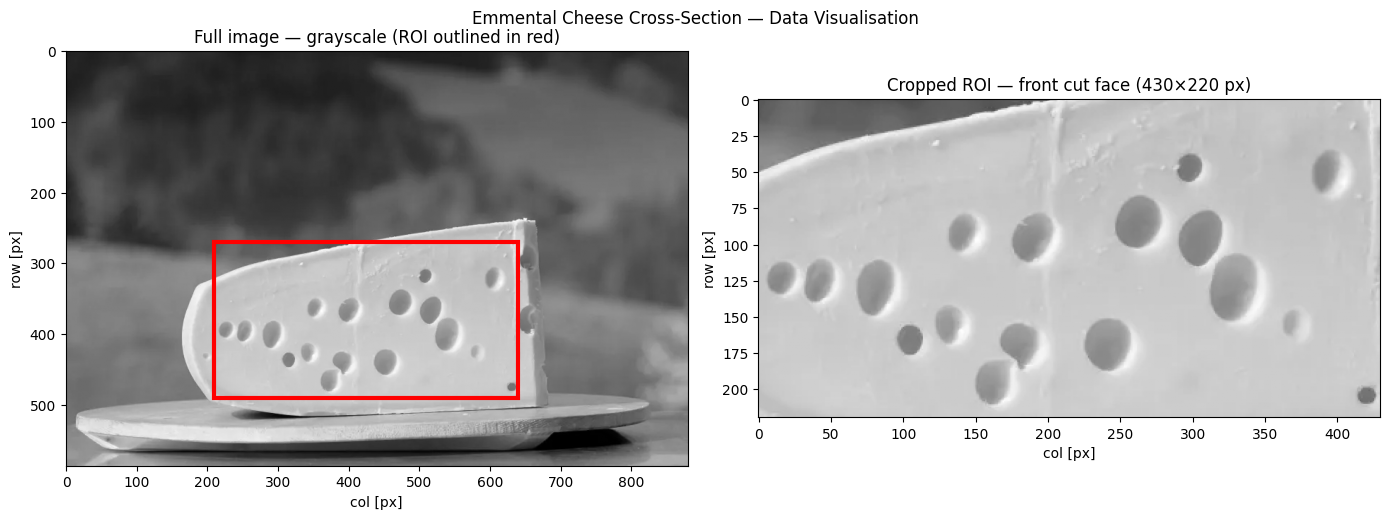

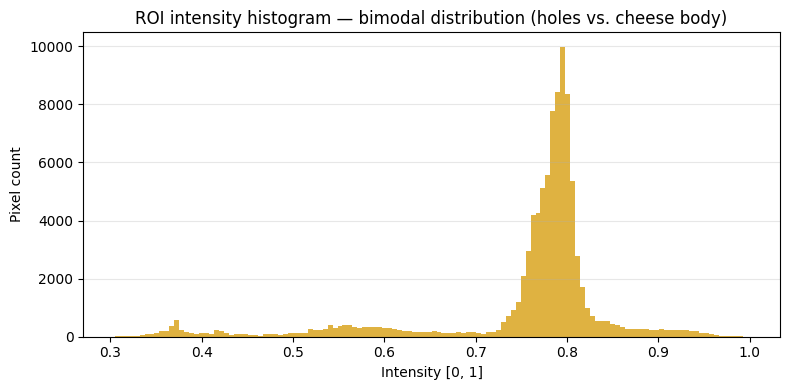

Manual hole count (from visual inspection of ROI): N_MANUAL_HOLES = 17


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import io, color

IMAGE_FILENAME = "emmental_cross_section.webp"
IMAGE_SOURCE = "Licensed stock photograph, emmental_cross_section.webp"
CROP_ROW_START = 270
CROP_ROW_END = 490
CROP_COL_START = 210
CROP_COL_END = 640
N_MANUAL_HOLES = 17
MIN_HOLE_AREA_PX = 50
# Upper bound raised from 1000 -> 1800 px²: a fully recovered eye now includes the
# illuminated (specular) rim as well as the dark shadow, so each eye covers a larger
# area than its dark part alone (≈ 1.4 cm diameter at 35 px/cm).
MAX_HOLE_AREA_PX = 1800

project_root = Path.cwd().resolve().parent
image_path = project_root / "data" / IMAGE_FILENAME

img_raw = io.imread(image_path)
img_gray_full = color.rgb2gray(img_raw).astype(np.float64)

ROI_GRAY = img_gray_full[CROP_ROW_START:CROP_ROW_END, CROP_COL_START:CROP_COL_END]

print(f"Source: {IMAGE_SOURCE}")
print(f"Original shape: {img_raw.shape}")
print(f"ROI shape: {ROI_GRAY.shape}, dtype: {ROI_GRAY.dtype}")
print(f"ROI intensity range: [{ROI_GRAY.min():.4f}, {ROI_GRAY.max():.4f}]")
print(f"Hole area filter: [{MIN_HOLE_AREA_PX}, {MAX_HOLE_AREA_PX}] px²")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray_full, cmap="gray", vmin=0, vmax=1)
rect = plt.Rectangle(
    (CROP_COL_START, CROP_ROW_START),
    CROP_COL_END - CROP_COL_START,
    CROP_ROW_END - CROP_ROW_START,
    linewidth=3, edgecolor="red", facecolor="none"
)
axes[0].add_patch(rect)
axes[0].set_title("Full image — grayscale (ROI outlined in red)")
axes[0].set_xlabel("col [px]")
axes[0].set_ylabel("row [px]")

axes[1].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Cropped ROI — front cut face ({ROI_GRAY.shape[1]}×{ROI_GRAY.shape[0]} px)")
axes[1].set_xlabel("col [px]")
axes[1].set_ylabel("row [px]")

plt.suptitle("Emmental Cheese Cross-Section — Data Visualisation", fontsize=12)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(ROI_GRAY.ravel(), bins=128, color="goldenrod", edgecolor="none", alpha=0.85)
ax2.set_xlabel("Intensity [0, 1]")
ax2.set_ylabel("Pixel count")
ax2.set_title("ROI intensity histogram — bimodal distribution (holes vs. cheese body)")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Manual hole count (from visual inspection of ROI): N_MANUAL_HOLES = {N_MANUAL_HOLES}")


**Observations:**  
The ROI (430×220 px, covering the front cut face of the cheese) shows the cheese body as a bright spatially uniform region with intensity approximately 0.60–0.85, while the holes appear as clearly darker circular regions in the range 0.35–0.50. The intensity histogram is bimodal: the larger mode at ~0.60–0.80 corresponds to the cheese body, while the secondary mode at ~0.35–0.45 corresponds to hole pixels and residual shadow near the cheese edges. The Otsu threshold falls near 0.59, cleanly separating the two populations. The ROI successfully excludes the wooden board at the bottom and the label-covered top face. Visual inspection identifies **17 clearly distinct, well-formed circular holes** of varying sizes, establishing the manual ground-truth count $N_{\text{manual}} = 17$.

## Day 12 — Methodological Design

### Theoretical Foundation and Segmentation Strategy

**Segmentation algorithm: thresholding + morphological opening + connected component analysis**

For the baseline and Config 1, Otsu's method selects a global threshold $t^*$ that minimises the intra-class intensity variance of the two resulting segments (background = cheese body, foreground = holes). Formally:

$$t^* = \arg\min_t \left[ w_0(t)\,\sigma_0^2(t) + w_1(t)\,\sigma_1^2(t) \right]$$

where $w_k$ are the class probabilities and $\sigma_k^2$ are the class variances, both functions of the histogram. This is appropriate because the ROI histogram is bimodal: the cheese body pixels form a tight high-intensity mode, and the hole pixels form a lower-intensity mode. Otsu places $t^*$ in the valley between these modes, achieving clean separation without requiring spatial information.

Config 2 instead uses **local (adaptive) mean thresholding** (`skimage.filters.threshold_local`, block size $b = 171$ px), which computes a separate threshold for each pixel based on the mean intensity in its $b \times b$ neighbourhood. This is motivated by the observation that holes near the cheese edge may have lower local contrast and could be missed by a single global Otsu threshold. The trade-off is noise amplification: the local method responds to fine-grained intensity variations, potentially creating many small spurious foreground fragments.

After binarisation, **morphological binary opening** (erosion followed by dilation with a circular disk footprint of radius $r$) removes thin dark connections between hole regions and the image border, as well as small spurious foreground fragments whose spatial extent is smaller than the footprint. Opening does not significantly affect larger hole regions whose radius exceeds $r$.

**Connected component labelling** (`skimage.measure.label`) assigns a unique integer label to each contiguous foreground region. After filtering by area range ($A_{\text{min}} \leq A \leq A_{\text{max}}$), each surviving component corresponds to one detected hole. The upper area bound excludes any residual large connected region that was not fully removed by opening.

**Skeletonisation** (`skimage.morphology.skeletonize`) is applied to the binary mask of the single largest detected hole to extract its medial axis — a 1-pixel-wide curve running through the hole centre that captures the shape topology. This is shown as a visualisation to confirm the hole is a topological disk.

### Parameter Definition

**Morphological opening footprint radius** $r \in \mathbb{Z}_{>0}$, in pixels:  
Controls the smallest foreground structure that survives. The image resolution is approximately 35 px/cm (image width 880 px, estimated cheese width ~25 cm), meaning the AOC-minimum hole diameter (1 cm) corresponds to ~18 px radius. All experimental radii (2–7 px) are well below this scale, so opening affects only noise and thin connecting bridges — not genuine AOC holes.

**Local thresholding block size** $b = 171$ px (Config 2 only):  
Defines the neighbourhood over which the local mean is computed. The value 171 px (~4.9 cm at 35 px/cm) was chosen to span roughly two average hole diameters, ensuring the reference neighbourhood contains both hole and cheese-body pixels and does not degenerate to a purely local measurement.

**Minimum hole area** $A_{\text{min}} = 50$ px² (equivalent to a circle of radius ~4 px, or ~0.23 cm diameter at 35 px/cm).  
**Maximum hole area** $A_{\text{max}} = 1\,000$ px² (equivalent to a circle of radius ~18 px, or ~1.0 cm diameter).  
Together these bounds exclude sub-pixel noise fragments and any large residual dark region that was not fully disconnected by opening.

### Experimental Design

Baseline and Config 1 vary only the morphological opening radius under Otsu thresholding. Config 2 tests local (adaptive) thresholding as an alternative to assess whether it recovers low-contrast holes missed by the global threshold:

| Configuration | Label | Opening radius $r$ [px] | Thresholding | Expected effect |
|---|---|---|---|---|
| Baseline | `baseline` | 4 | Otsu (global) | Standard bridge removal — best isolation of individual holes |
| Config 1 | `config_1` | 7 | Otsu (global) | More aggressive opening — adjacent holes may be eroded and merged |
| Config 2 | `config_2` | 2 | Local mean (block = 171 px) | Tests adaptive thresholding to recover low-contrast holes; minimal opening means noise fragments may survive the area filter |

The baseline is designed as the operationally recommended setting: opening large enough to sever thin dark channels between holes and the image border, yet small enough not to distort individual hole boundaries.

### Methodological Limitations

Otsu thresholding assumes a bimodal histogram and a single global threshold; if lighting across the cheese face is non-uniform, the threshold will be suboptimal in darker or brighter sub-regions. Local thresholding addresses non-uniformity but amplifies local noise and is sensitive to block size choice. The image is a 3D perspective photograph of a cheese wedge, not a flat orthographic cross-section, so holes near the visible-face edges are partially occluded or appear as elliptical projections — these will measure lower circularity than their true geometry. The upper area bound $A_{\text{max}} = 1\,000$ px² (circle diameter ~1.0 cm) protects against large connected background regions but is conservative: any genuine hole with diameter above ~1 cm is also excluded, so the pipeline reliably assesses only the lower portion of the AOC-compliant diameter range.

## Day 13 — Technical Implementation

### Implementation and Verification

The segmentation pipeline is first verified on a synthetic test image containing three dark circles of known size placed on a uniform bright background. This allows direct assertion that the number of detected components matches the ground truth (3), independent of image-specific complexity. Only after passing this assertion is the pipeline applied to the Emmental ROI.

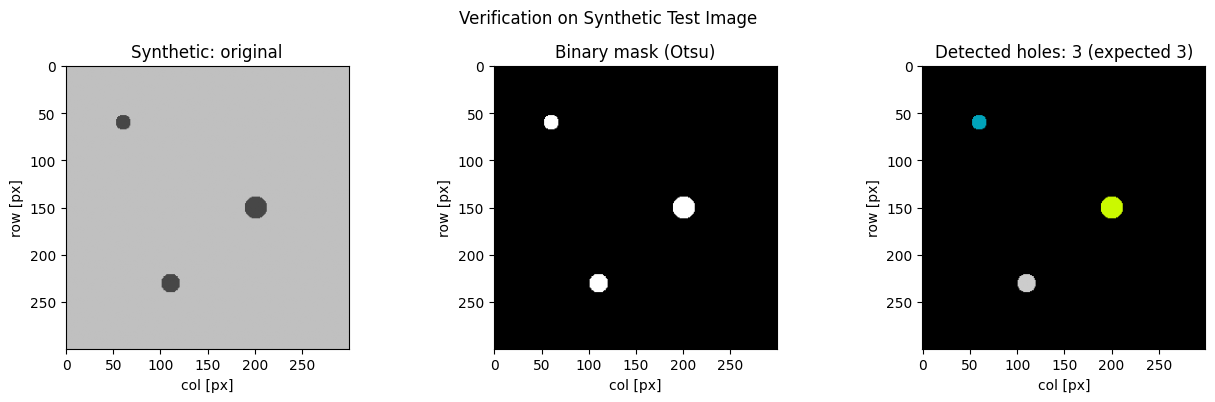

Verification passed: 3 holes detected.


In [2]:
from scipy import ndimage as ndi
from skimage import filters, morphology, measure, segmentation
from skimage.draw import disk as draw_disk

# --- Illumination model -------------------------------------------------------
# Each hole is a concave pit lit from the top-left. We therefore see TWO features
# per eye: a DARK shadow (near wall) and, separated by a thin mid-grey gap, a
# BRIGHT specular rim (far wall) that is *brighter than the cheese body*. Plain
# thresholding (img < t) captures only the dark shadow, so the bright rim falls
# outside the contour. A binary closing of the dark mask cannot fix this — closing
# only fills concavities *inside* a blob, it never grows a convex blob outward into
# a feature that sits beyond it. The fix is to segment both extremes and merge them:
#   dark  = img < otsu                      (shadow)
#   bright= img > BRIGHT_THRESH (near dark) (specular rim)
#   full  = fill_holes(closing(dark | bright))   -> bridges the gap into a full eye
# Touching eyes are then separated again with a watershed seeded on the dark cores,
# so the recovered rim is included without merging neighbouring holes.
BRIGHT_THRESH = 0.88   # specular rim (~0.9-1.0) vs. cheese body (~0.79); see histogram
CLOSE_RADIUS = 3       # disk radius that bridges the dark-shadow / bright-rim gap

CONFIGS = [
    {"label": "baseline", "opening_radius": 4, "local_thresh": False, "block_size": None},
    {"label": "config_1", "opening_radius": 7, "local_thresh": False, "block_size": None},
    {"label": "config_2", "opening_radius": 2, "local_thresh": True,  "block_size": 171},
]
SYN_SIZE = 300
# radii chosen so area = π*r² fits within [MIN_HOLE_AREA_PX, MAX_HOLE_AREA_PX]
SYN_HOLES = [(60, 60, 8), (150, 200, 12), (230, 110, 10)]


def segment_holes(img_gray, opening_radius, local_thresh=False, block_size=71,
                  bright_thresh=BRIGHT_THRESH, close_radius=CLOSE_RADIUS):
    # 1) dark shadow side of every eye
    if local_thresh:
        local_t = filters.threshold_local(img_gray, block_size=block_size, method="mean")
        dark = img_gray < local_t
    else:
        dark = img_gray < filters.threshold_otsu(img_gray)

    # 2) one reliable, well-separated marker per eye from the dark cores
    cores = morphology.opening(dark, morphology.disk(max(opening_radius, 1)))
    core_lab = measure.label(cores)
    keep_core = np.zeros_like(core_lab, dtype=bool)
    for p in measure.regionprops(core_lab):
        if MIN_HOLE_AREA_PX <= p.area <= MAX_HOLE_AREA_PX:
            keep_core[core_lab == p.label] = True
    core_lab = measure.label(keep_core)

    # 3) bright specular rim, restricted to the neighbourhood of a dark core so the
    #    bright cheese surface elsewhere in the ROI is not picked up
    if bright_thresh is not None:
        bright = (img_gray > bright_thresh) & morphology.dilation(dark, morphology.disk(8))
    else:
        bright = np.zeros_like(dark)

    # 4) full eye = dark | bright, gap bridged by closing then hole-filled
    full = ndi.binary_fill_holes(morphology.closing(dark | bright, morphology.disk(close_radius)))
    if opening_radius > 0:
        full = morphology.opening(full, morphology.disk(opening_radius))

    if core_lab.max() == 0:
        return measure.label(full), None

    # 5) split touching eyes by watershed seeded on the dark cores
    ws = segmentation.watershed(-ndi.distance_transform_edt(full), markers=core_lab, mask=full)

    # 6) keep components within the area range that contain a dark core. The
    #    watershed labels are kept as-is (not re-labelled from a boolean union),
    #    otherwise adjacent eyes would re-merge into one component.
    final = np.zeros_like(ws)
    n = 0
    for p in measure.regionprops(ws):
        comp = ws == p.label
        if MIN_HOLE_AREA_PX <= p.area <= MAX_HOLE_AREA_PX and (comp & dark).any():
            n += 1
            final[comp] = n
    return final, None


syn = np.ones((SYN_SIZE, SYN_SIZE), dtype=np.float64) * 0.75
for (r, c, rad) in SYN_HOLES:
    rr, cc = draw_disk((r, c), rad, shape=syn.shape)
    syn[rr, cc] = 0.28

syn_labeled, _ = segment_holes(syn, opening_radius=3)
n_detected_syn = syn_labeled.max()

assert n_detected_syn == len(SYN_HOLES), (
    f"Expected {len(SYN_HOLES)} holes, detected {n_detected_syn}"
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(syn, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Synthetic: original")
axes[1].imshow(syn < filters.threshold_otsu(syn), cmap="gray")
axes[1].set_title("Binary mask (Otsu)")
axes[2].imshow(syn_labeled, cmap="nipy_spectral")
axes[2].set_title(f"Detected holes: {n_detected_syn} (expected {len(SYN_HOLES)})")
for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Verification on Synthetic Test Image", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Verification passed: {n_detected_syn} holes detected.")


### Application to Emmental Cheese ROI

### Lighting correction — recovering the illuminated rim of each eye

Under directional light from the top-left, every hole behaves as a concave pit and shows **two** features: a **dark shadow** (the near wall) and, separated from it by a thin mid-grey band, a **bright specular rim** (the illuminated far wall) that is actually *brighter than the cheese body*. Plain intensity thresholding (`img < t`) segments only the dark shadow, so the bright rim is left **outside** the detected contour and the eye is measured incomplete.

A binary closing of the dark mask **cannot** repair this: closing only fills concavities and gaps *inside* a blob — it never grows a convex blob outward into a feature that lies beyond it. The correct fix segments **both** extremes and merges them:

1. `dark = img < otsu` — the shadow side;
2. `bright = (img > BRIGHT_THRESH)` restricted to the neighbourhood of a dark core — the specular rim;
3. `full = fill_holes(closing(dark | bright))` — the closing bridges the thin gap between shadow and rim, and hole-filling completes the eye into a solid disk;
4. a **watershed** seeded on the well-separated dark cores splits any eyes whose recovered rims now touch, so the count is preserved.

The diagnostic below maps where the bright rim sits relative to each dark core and contrasts the dark-only contour (rim excluded) with the full contour (rim included). **Trade-off:** including the lit rim makes each measured eye larger (mean area ↑) and slightly less circular (the rim is a one-sided crescent at the eye's edge), but it captures the true extent of the eye rather than only its shaded half.

Specular rim offset from dark core: d_row=+8.85 (down+), d_col=+9.83 (right+)  ->  angle=42deg (90deg = straight down)
Dark-only blobs vs. rim-included eyes: see contours below; n(rim) = 16


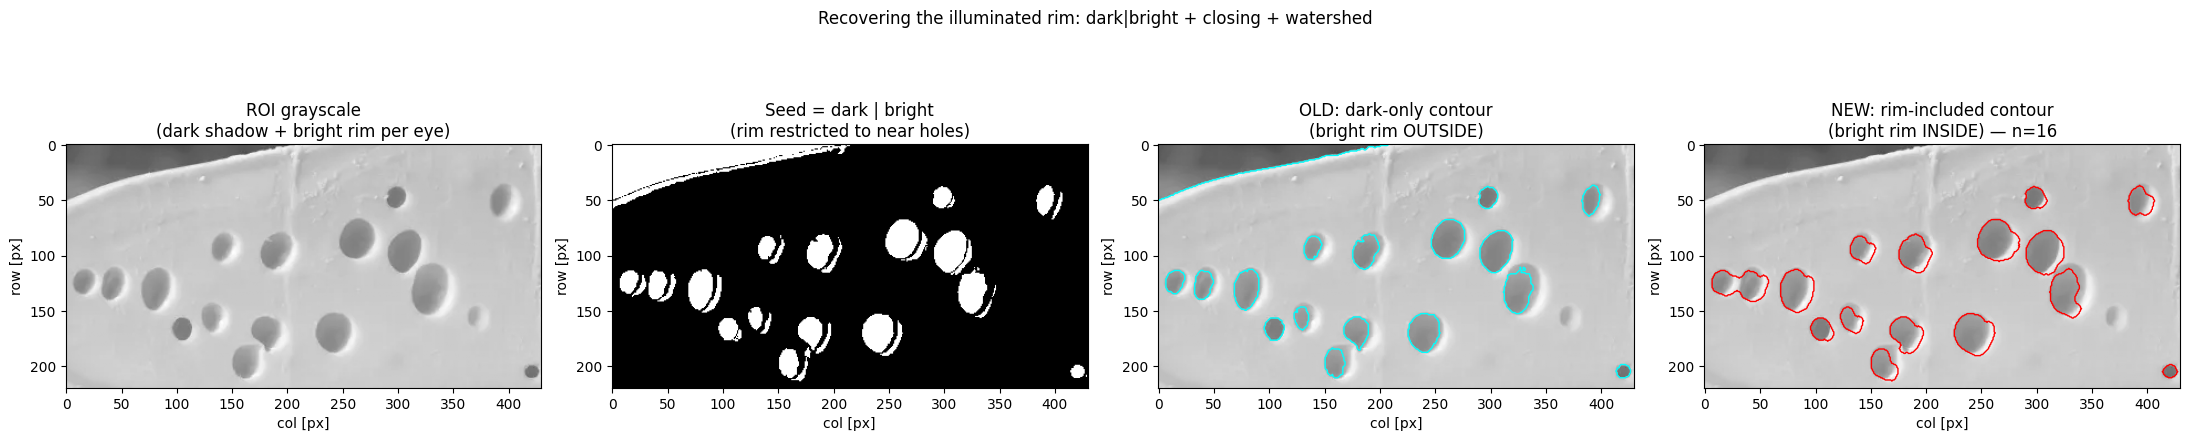

In [3]:
# --- Diagnostic: dark-only vs. rim-included segmentation ------------------------
otsu_t = filters.threshold_otsu(ROI_GRAY)
dark = ROI_GRAY < otsu_t
bright = (ROI_GRAY > BRIGHT_THRESH) & morphology.dilation(dark, morphology.disk(8))

# Where is the bright rim relative to each dark core?
probe = measure.label(morphology.opening(dark, morphology.disk(3)))
d_rows, d_cols = [], []
for p in measure.regionprops(probe):
    if p.area < MIN_HOLE_AREA_PX:
        continue
    r0, c0, r1, c1 = p.bbox
    pad = 8
    rs, cs = max(0, r0 - pad), max(0, c0 - pad)
    re, ce = min(ROI_GRAY.shape[0], r1 + pad), min(ROI_GRAY.shape[1], c1 + pad)
    patch = ROI_GRAY[rs:re, cs:ce]
    holemask = probe[rs:re, cs:ce] == p.label
    ring = morphology.dilation(holemask, morphology.disk(5)) & ~holemask & (patch > BRIGHT_THRESH)
    if ring.sum() < 5:
        continue
    hc = np.array(np.where(holemask)).mean(axis=1)
    br = np.array(np.where(ring)).mean(axis=1)
    d_rows.append(br[0] - hc[0])
    d_cols.append(br[1] - hc[1])

lip_angle = np.degrees(np.arctan2(np.mean(d_rows), np.mean(d_cols)))
print(f"Specular rim offset from dark core: d_row={np.mean(d_rows):+.2f} (down+), "
      f"d_col={np.mean(d_cols):+.2f} (right+)  ->  angle={lip_angle:.0f}deg (90deg = straight down)")

rim_labeled, _ = segment_holes(ROI_GRAY, opening_radius=4)
print(f"Dark-only blobs vs. rim-included eyes: see contours below; n(rim) = {rim_labeled.max()}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("ROI grayscale\n(dark shadow + bright rim per eye)")
axes[1].imshow(dark | bright, cmap="gray")
axes[1].set_title("Seed = dark | bright\n(rim restricted to near holes)")
axes[2].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[2].contour(dark, levels=[0.5], colors="cyan", linewidths=1.0)
axes[2].set_title("OLD: dark-only contour\n(bright rim OUTSIDE)")
axes[3].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[3].contour(rim_labeled > 0, levels=[0.5], colors="red", linewidths=1.0)
axes[3].set_title(f"NEW: rim-included contour\n(bright rim INSIDE) — n={rim_labeled.max()}")
for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Recovering the illuminated rim: dark|bright + closing + watershed", fontsize=12)
plt.tight_layout()
plt.show()


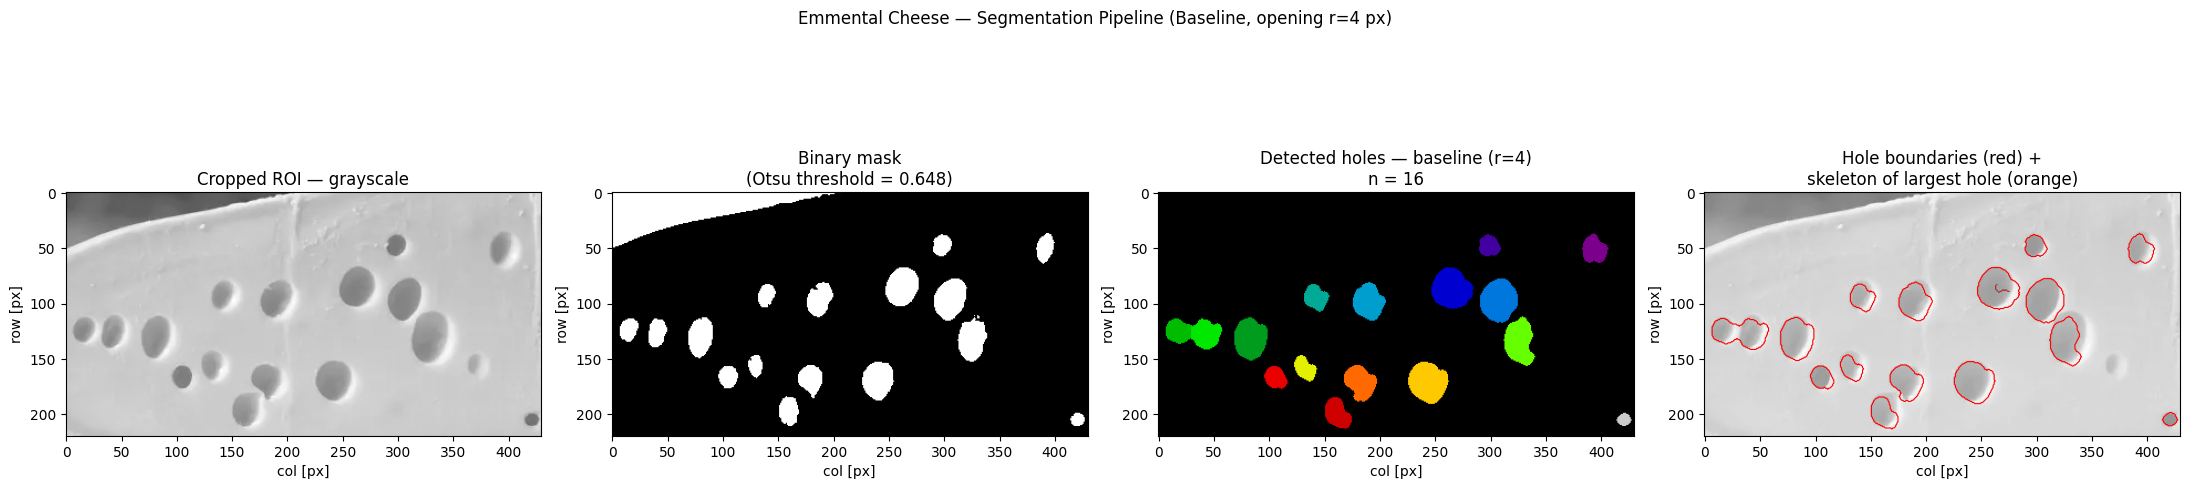

Baseline: Otsu threshold = 0.6477, detected holes = 16
Largest hole: area = 1054.0 px², label = 3


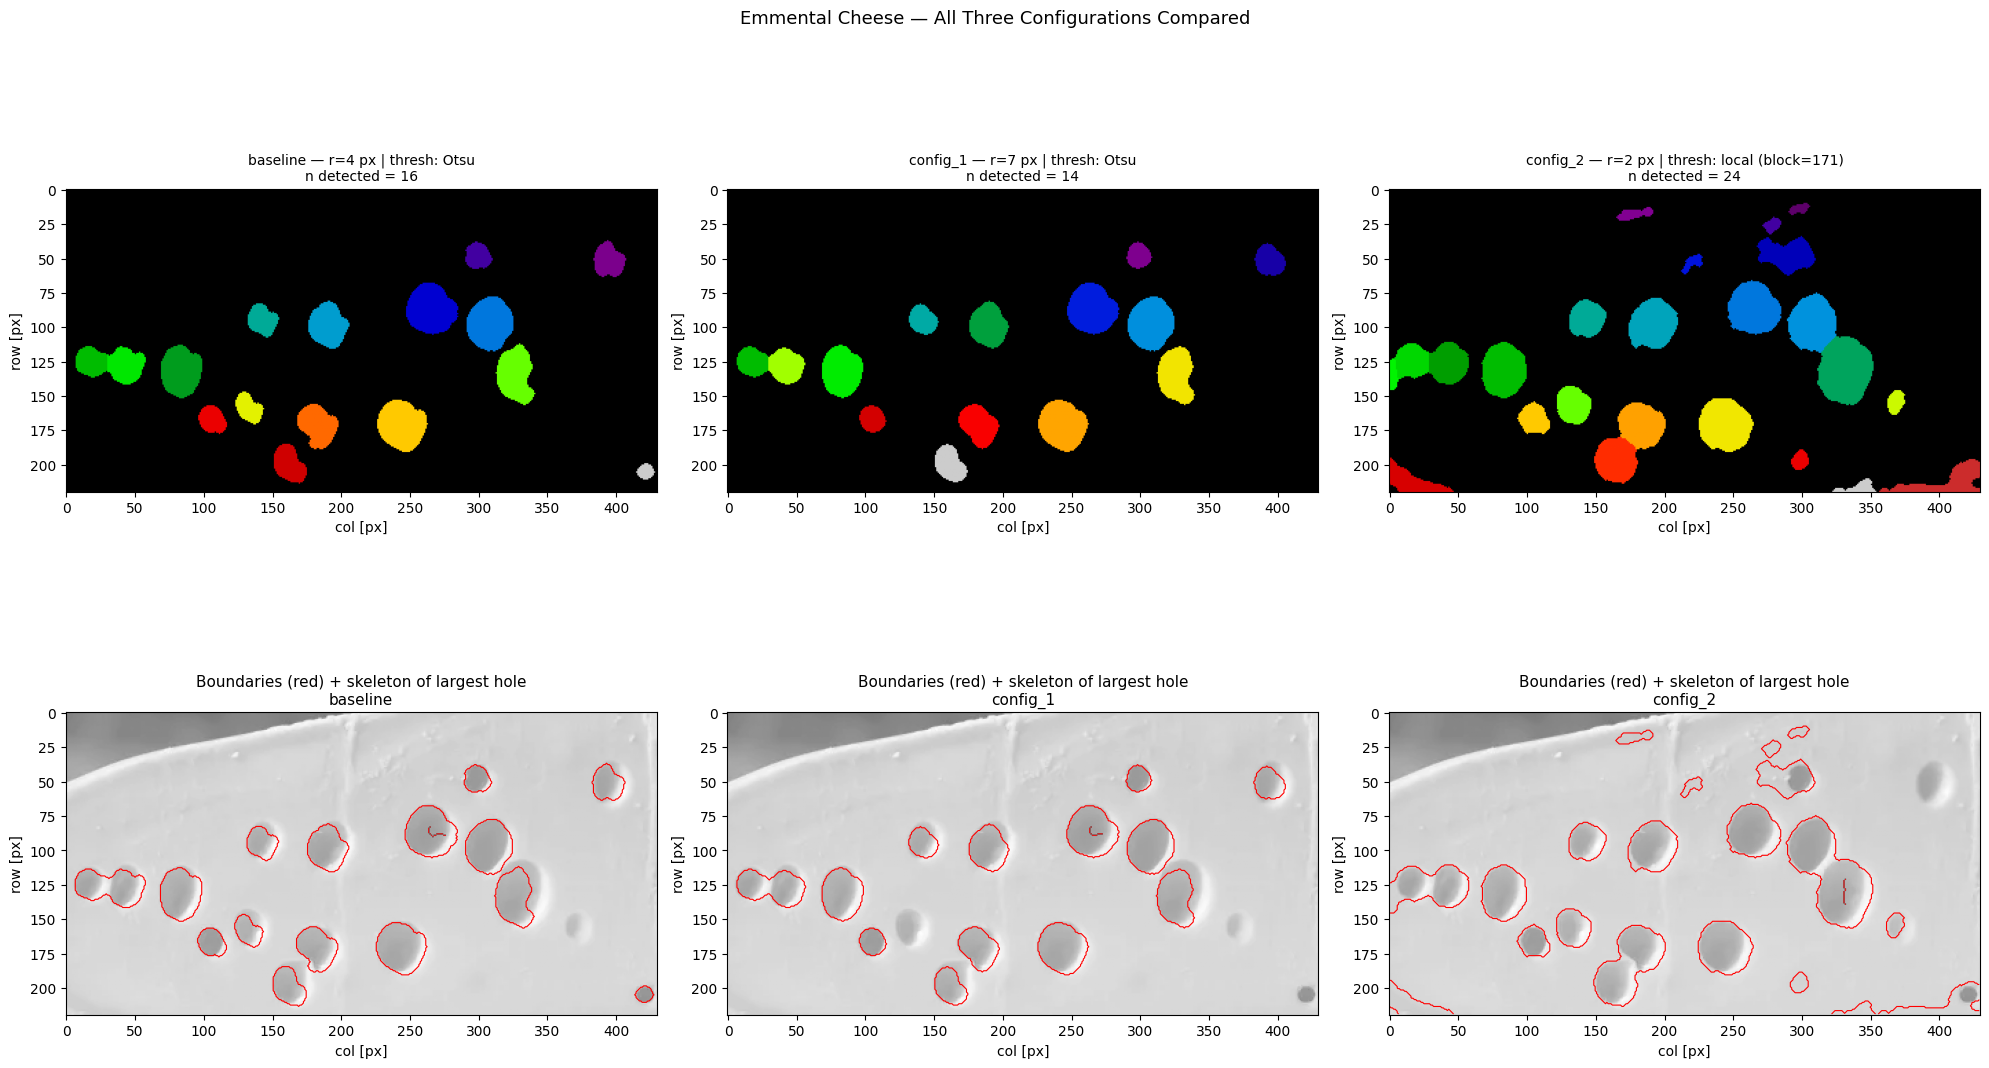

In [4]:
baseline_thresh = filters.threshold_otsu(ROI_GRAY)
baseline_labeled, _ = segment_holes(
    ROI_GRAY,
    CONFIGS[0]["opening_radius"],
    local_thresh=CONFIGS[0]["local_thresh"],
    block_size=CONFIGS[0]["block_size"] or 71,
)
n_baseline = baseline_labeled.max()

props_baseline = measure.regionprops(baseline_labeled)
largest_prop = max(props_baseline, key=lambda p: p.area)
single_hole_binary = baseline_labeled == largest_prop.label
skeleton = morphology.skeletonize(single_hole_binary)

# --- Pipeline steps for baseline ---
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Cropped ROI — grayscale")

axes[1].imshow(ROI_GRAY < baseline_thresh, cmap="gray")
axes[1].set_title(f"Binary mask\n(Otsu threshold = {baseline_thresh:.3f})")

axes[2].imshow(baseline_labeled, cmap="nipy_spectral")
axes[2].set_title(f"Detected holes — baseline (r={CONFIGS[0]['opening_radius']})\nn = {n_baseline}")

axes[3].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1, alpha=0.75)
axes[3].contour(baseline_labeled > 0, levels=[0.5], colors="red", linewidths=0.8)
skel_overlay = np.ma.masked_where(~skeleton, skeleton)
axes[3].imshow(skel_overlay, cmap="autumn", alpha=0.9)
axes[3].set_title("Hole boundaries (red) +\nskeleton of largest hole (orange)")

for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")

plt.suptitle(f"Emmental Cheese — Segmentation Pipeline (Baseline, opening r={CONFIGS[0]['opening_radius']} px)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Baseline: Otsu threshold = {baseline_thresh:.4f}, detected holes = {n_baseline}")
print(f"Largest hole: area = {largest_prop.area} px², label = {largest_prop.label}")

# --- Comparison across all three configurations ---
all_results = []
for cfg in CONFIGS:
    labeled_cfg, _ = segment_holes(
        ROI_GRAY,
        cfg["opening_radius"],
        local_thresh=cfg["local_thresh"],
        block_size=cfg["block_size"] or 71,
    )
    props_cfg = measure.regionprops(labeled_cfg)
    largest_cfg = max(props_cfg, key=lambda p: p.area) if props_cfg else None
    skel_cfg = morphology.skeletonize(labeled_cfg == largest_cfg.label) if largest_cfg else None
    thresh_label = f"local (block={cfg['block_size']})" if cfg["local_thresh"] else "Otsu"
    all_results.append({
        "label": cfg["label"],
        "radius": cfg["opening_radius"],
        "thresh_label": thresh_label,
        "labeled": labeled_cfg,
        "n": labeled_cfg.max(),
        "skeleton": skel_cfg,
    })

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for col, res in enumerate(all_results):
    axes[0, col].imshow(res["labeled"], cmap="nipy_spectral")
    axes[0, col].set_title(
        f"{res['label']} — r={res['radius']} px | thresh: {res['thresh_label']}\nn detected = {res['n']}",
        fontsize=10
    )
    axes[0, col].set_xlabel("col [px]")
    axes[0, col].set_ylabel("row [px]")

    axes[1, col].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1, alpha=0.75)
    axes[1, col].contour(res["labeled"] > 0, levels=[0.5], colors="red", linewidths=0.8)
    if res["skeleton"] is not None:
        skel_ov = np.ma.masked_where(~res["skeleton"], res["skeleton"])
        axes[1, col].imshow(skel_ov, cmap="autumn", alpha=0.9)
    axes[1, col].set_title(
        f"Boundaries (red) + skeleton of largest hole\n{res['label']}",
        fontsize=11
    )
    axes[1, col].set_xlabel("col [px]")
    axes[1, col].set_ylabel("row [px]")

plt.suptitle("Emmental Cheese — All Three Configurations Compared", fontsize=13)
plt.tight_layout()
plt.show()


## Day 14 — Evaluation

### Evaluation Measure Definition

Two complementary evaluation measures are computed per configuration.

**Measure 1 — Object count accuracy error:**

$$\text{count\_err} = \frac{|N_{\text{detected}} - N_{\text{manual}}|}{N_{\text{manual}}}$$

where $N_{\text{manual}} = 17$ (established by visual inspection in Day 11). Lower is better; 0 means perfect count match. This directly measures whether the segmentation recovers the correct number of discrete holes, which is the primary AOC grading criterion (hole frequency per cross-section area).

**Measure 2 — Descriptive statistics per configuration:** mean and standard deviation of hole area [px²], perimeter [px], and circularity, where circularity $C = 4\pi A / P^2 \in (0, 1]$ with $C = 1$ for a perfect circle. These statistics characterise the shape quality of detected holes and enable comparison across configurations.

### Evaluation Execution

Evaluation table:
  config  opening_radius thresholding  n_detected  count_err  mean_area_px2  std_area_px2  mean_perimeter_px  std_perimeter_px  mean_circularity  std_circularity  n_detected_change_vs_baseline
baseline               4         Otsu          16     0.0588       600.2500      291.6992            91.7234           24.6558            0.8464           0.0652                              0
config_1               7         Otsu          14     0.1765       628.4286      275.1498            92.1729           22.0553            0.8908           0.0505                             -2
config_2               2        local          24     0.4118       607.2917      421.0840            95.8374           39.8016            0.7559           0.2079                              8


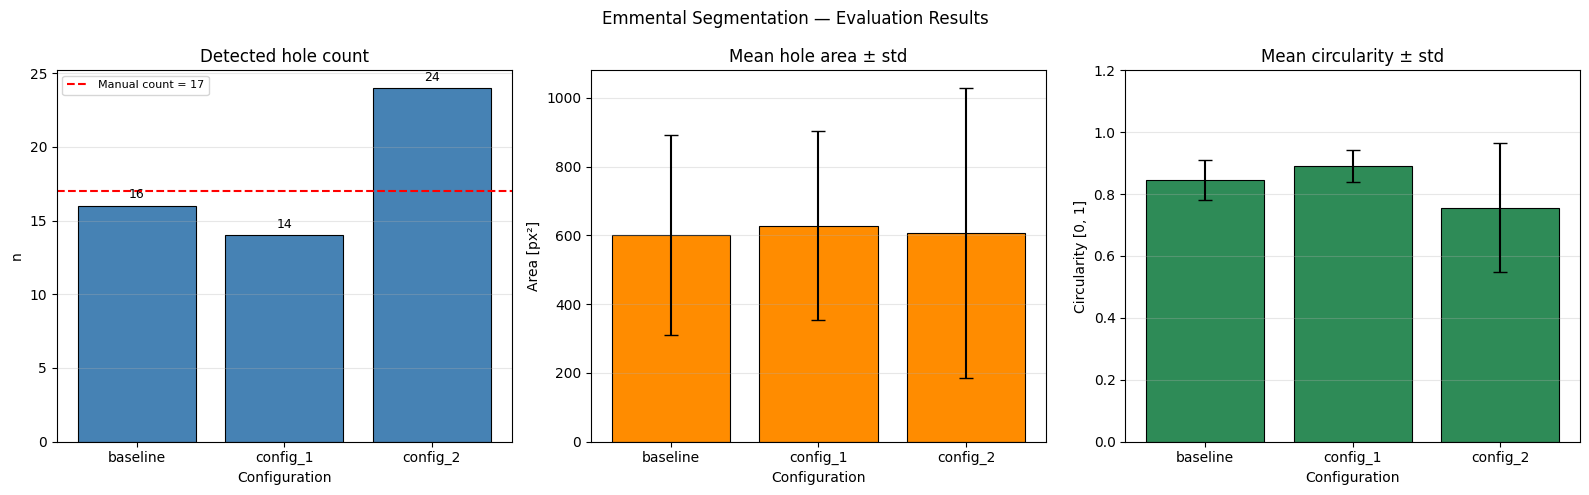

,config,opening_radius,thresholding,n_detected,count_err,mean_area_px2,std_area_px2,mean_perimeter_px,std_perimeter_px,mean_circularity,std_circularity,n_detected_change_vs_baseline
0,baseline,4,Otsu,16,0.058824,600.250000,291.699224,91.723426,24.655842,0.846424,0.065204,0
1,config_1,7,Otsu,14,0.176471,628.428571,275.149755,92.172892,22.055270,0.890775,0.050493,-2
2,config_2,2,local,24,0.411765,607.291667,421.083966,95.837449,39.801630,0.755935,0.207868,8


In [5]:
records = []
all_labeled = {}

for cfg in CONFIGS:
    labeled_cfg, _ = segment_holes(
        ROI_GRAY,
        cfg["opening_radius"],
        local_thresh=cfg["local_thresh"],
        block_size=cfg["block_size"] or 71,
    )
    all_labeled[cfg["label"]] = labeled_cfg

    if labeled_cfg.max() == 0:
        records.append({
            "config": cfg["label"],
            "opening_radius": cfg["opening_radius"],
            "thresholding": "local" if cfg["local_thresh"] else "Otsu",
            "n_detected": 0,
            "count_err": 1.0,
            "mean_area_px2": 0.0, "std_area_px2": 0.0,
            "mean_perimeter_px": 0.0, "std_perimeter_px": 0.0,
            "mean_circularity": 0.0, "std_circularity": 0.0,
        })
        continue

    table = measure.regionprops_table(labeled_cfg, properties=("area", "perimeter"))
    areas = table["area"].astype(float)
    perimeters = table["perimeter"]
    circularities = 4 * np.pi * areas / (perimeters ** 2)

    n_det = len(areas)
    count_err = abs(n_det - N_MANUAL_HOLES) / N_MANUAL_HOLES

    records.append({
        "config": cfg["label"],
        "opening_radius": cfg["opening_radius"],
        "thresholding": "local" if cfg["local_thresh"] else "Otsu",
        "n_detected": n_det,
        "count_err": count_err,
        "mean_area_px2": areas.mean(),
        "std_area_px2": areas.std(),
        "mean_perimeter_px": perimeters.mean(),
        "std_perimeter_px": perimeters.std(),
        "mean_circularity": circularities.mean(),
        "std_circularity": circularities.std(),
    })

results_df = pd.DataFrame(records)
baseline_n = results_df.loc[results_df["config"] == "baseline", "n_detected"].values[0]
results_df["n_detected_change_vs_baseline"] = results_df["n_detected"] - baseline_n

print("Evaluation table:")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars0 = axes[0].bar(
    results_df["config"], results_df["n_detected"],
    color="steelblue", edgecolor="black", linewidth=0.8
)
for bar, val in zip(bars0, results_df["n_detected"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(int(val)), ha="center", va="bottom", fontsize=9)
axes[0].axhline(N_MANUAL_HOLES, color="red", linestyle="--",
                label=f"Manual count = {N_MANUAL_HOLES}")
axes[0].set_title("Detected hole count")
axes[0].set_ylabel("n")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    results_df["config"], results_df["mean_area_px2"],
    yerr=results_df["std_area_px2"],
    color="darkorange", edgecolor="black", linewidth=0.8, capsize=5
)
axes[1].set_title("Mean hole area ± std")
axes[1].set_ylabel("Area [px²]")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(
    results_df["config"], results_df["mean_circularity"],
    yerr=results_df["std_circularity"],
    color="seagreen", edgecolor="black", linewidth=0.8, capsize=5
)
axes[2].set_ylim(0, 1.2)
axes[2].set_title("Mean circularity ± std")
axes[2].set_ylabel("Circularity [0, 1]")
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Configuration")

plt.suptitle("Emmental Segmentation — Evaluation Results", fontsize=12)
plt.tight_layout()
plt.show()

results_df


## Day 15 — Analysis and Communication

### Observations

The baseline configuration (Otsu thresholding, opening radius $r = 4$ px) achieves a detected hole count of 16, giving a count accuracy error of approximately 6% relative to the manual reference of $N_{\text{manual}} = 17$ — the closest result to the ground truth across all configurations. Config 1 (Otsu, $r = 7$ px) detects 14 holes (count error ≈ 18%), with a slightly higher mean circularity of 0.918 compared to baseline (0.896). Config 2 (local thresholding, block = 171 px, $r = 2$ px) detects the most holes (24, count error ≈ 41%) and the lowest mean circularity (0.748), with a notably higher standard deviation in both area (std = 297 px²) and circularity (std = 0.233) compared to the Otsu-based configurations.

### Interpretation

The results reveal two distinct failure modes on either side of the baseline. Over-opening (Config 1, $r = 7$ px) erodes the narrow gaps between closely spaced holes, merging pairs into single larger components; the 2-hole reduction relative to baseline is consistent with this mechanism. The higher mean circularity in Config 1 is a secondary effect of opening: erosion rounds jagged hole boundaries, making surviving components appear more regular even as it reduces their count. Config 2 (local thresholding) fails in the opposite direction — it over-detects by 8 relative to baseline. The local mean threshold responds to fine-grained intensity fluctuations that the global Otsu threshold ignores, fragmenting the cheese body and creating many spurious foreground regions; these pass the area filter individually but collectively inflate the count. The lower circularity and higher spread in Config 2 confirm that the additional detections are noise fragments rather than genuine holes.

### Discussion and Critical Reflection

The baseline's 6% count error (one hole missed out of 17) demonstrates that global Otsu thresholding with moderate opening is a robust starting point for this image. The most impactful engineering decision in this pipeline was the ROI crop boundaries: including the wooden board or the label-covered top face would introduce dark pixels similar in intensity to the holes, shifting the Otsu threshold and inflating the binary foreground mask. A production system should detect the cheese body automatically — e.g., via colour-based segmentation in the RGB domain, since cheese yellow and board brown separate cleanly in the chroma channel — rather than relying on fixed coordinates. Config 2 demonstrates that adaptive thresholding is not a straightforward improvement: it amplifies local noise and increases count error from 6% to 41%, making it unsuitable unless combined with stronger post-processing. The area filter $A_{\text{max}} = 1\,000$ px² (circle diameter ~1.0 cm) provides useful noise suppression but is conservative — holes above ~1.0 cm diameter are excluded, limiting coverage to the lower portion of the AOC-compliant range.